<a href="https://colab.research.google.com/github/iqraghori/TMDB-API-Movie-Data-Analysis/blob/main/the_movie_database_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TMDb API Movie Data Analysis**

## Import Libraries

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

## API Authentication

In [2]:
TMDB_API = userdata.get('TDBM_API')
#url = f"https://api.themoviedb.org/3/movie/popular?api_key={TMDB_API}&page=500"

# **FETCH MOVIE DATA**

In [3]:
movies = []
for i in range(1, 501):
  url = f"https://api.themoviedb.org/3/movie/popular?api_key={TMDB_API}&page={i}"
  response = requests.get(url)
  data = response.json()
  movies.extend(data['results'])

In [4]:
movies[0]

{'adult': False,
 'backdrop_path': '/rZfmzpixLKLR3Hg2u0WgC7XLFl8.jpg',
 'genre_ids': [27],
 'id': 1339713,
 'title': 'Obsession',
 'original_language': 'en',
 'original_title': 'Obsession',
 'overview': 'After breaking the mysterious "One Wish Willow" to win his crush\'s heart, a hopeless romantic finds himself getting exactly what he asked for but soon discovers that some desires come at a dark, sinister price.',
 'popularity': 711.9924,
 'poster_path': '/6X4qFYBsG3bpWDG2XIKqr04kFJa.jpg',
 'release_date': '2026-05-13',
 'softcore': False,
 'video': False,
 'vote_average': 7.9,
 'vote_count': 525}

## Convert JSON to DataFrame

In [5]:
df = pd.DataFrame(movies)
df.head(2)
df.shape

(10000, 15)

# **DATA CLEANING**


In [6]:
df_movie = df[['id','adult', 'title', 'release_date', 'popularity', 'vote_average', 'vote_count']]
df_movie.head(2)

,id,adult,title,release_date,popularity,vote_average,vote_count
0,1339713,False,Obsession,2026-05-13,711.9924,7.9,525
1,1433117,False,Kara,2026-04-30,461.3196,6.1,15


In [7]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   adult         10000 non-null  bool   
 2   title         10000 non-null  object 
 3   release_date  10000 non-null  object 
 4   popularity    10000 non-null  float64
 5   vote_average  10000 non-null  float64
 6   vote_count    10000 non-null  int64  
dtypes: bool(1), float64(2), int64(2), object(2)
memory usage: 478.6+ KB


In [8]:
df_movie.shape

(10000, 7)

In [9]:
#df_movie['id'].value_counts()[lambda x: x>1] returns a seires not  a dataframe
df_movie[df_movie[['id','title']].duplicated()]
df_movie = df_movie.drop_duplicates(subset=['id','title'])

In [10]:
df_movie.duplicated().sum()

np.int64(0)

In [11]:
df_movie.isnull().sum()

,0
id,0
adult,0
title,0
release_date,0
popularity,0
vote_average,0
vote_count,0


In [13]:
df_movie['adult'] = df_movie['adult'].astype(int)

# **EXPLORATORY DATA ANALYSIS EDA**

# Univariate Analysis

### KDE Plot

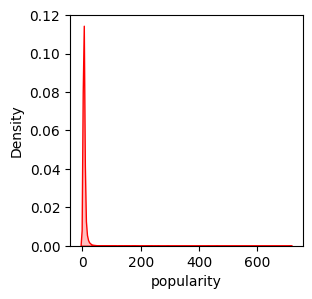

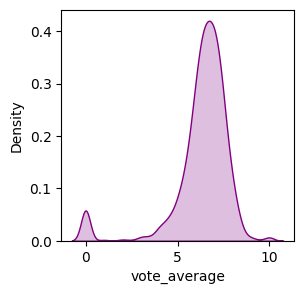

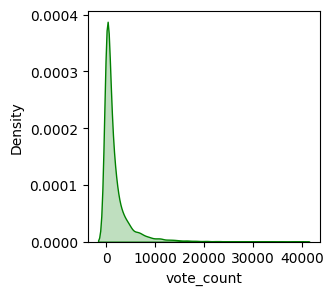

In [18]:
plt.rcParams["figure.figsize"] = (3,3)

sns.kdeplot(df_movie['popularity'],color='red',fill=True)
plt.show()

sns.kdeplot(df_movie['vote_average'],color='purple',fill=True)
plt.show()

sns.kdeplot(df_movie['vote_count'],color='green',fill=True)
plt.show()

### Box Plot removing outliers

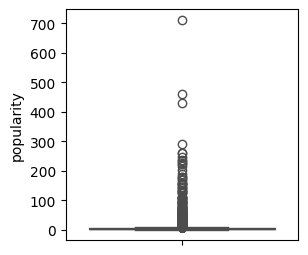

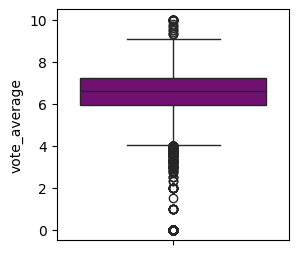

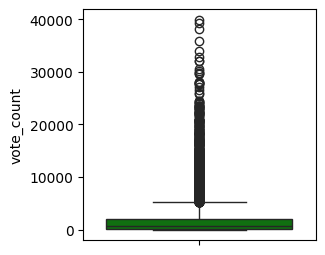

In [19]:
sns.boxplot(df_movie['popularity'],color='red',fill=True)
plt.show()

sns.boxplot(df_movie['vote_average'],color='purple',fill=True)
plt.show()

sns.boxplot(df_movie['vote_count'],color='green',fill=True)
plt.show()

# Bivarate Analysis

### Correlation Heatmap

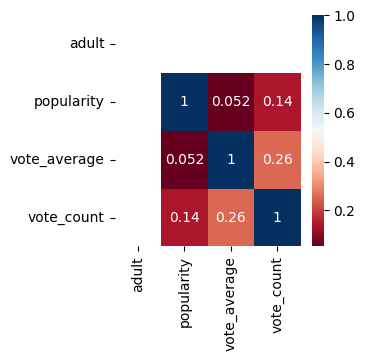

In [23]:
df_clean = df_movie.drop(columns=['id','title','release_date'])
df_clean.corr()
sns.heatmap(df_clean.corr(), annot=True, cmap='RdBu',)
plt.show()

High vote_count = more reliable vote_average. Low vote count ratings are misleading.Popularity and vote count move together, but popularity can spike without proportional votes (viral/controversial movies)

### Scatter Plots

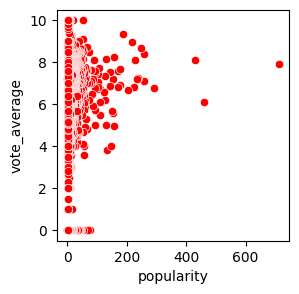

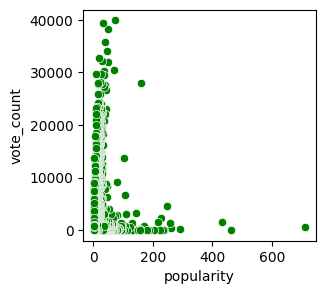

In [27]:
sns.scatterplot(data=df_movie, x='popularity', y='vote_average',color='red')
plt.show()

sns.scatterplot(data=df_movie, x='popularity', y='vote_count',color='green')
plt.show()

The dataset is heavily imbalanced — a small number of movies dominate in both popularity and vote count, while the majority are obscure low-engagement films. This is typical of real-world movie data following a power law distribution.

# **ADVANCED EDA**

### Weighted rating (IMDB-style)

In [28]:
df_movie.head(1)

,id,adult,title,release_date,popularity,vote_average,vote_count
0,1339713,0,Obsession,2026-05-13,711.9924,7.9,525


In [38]:
m = df_movie['vote_count'].quantile(0.7).astype(int)
c = df_movie['vote_average'].mean()

def weighted_rating(x, m=m, c=c):
  v = x['vote_count']
  r = x['vote_average']
  return (v/(v+m) * r) + (m/(m+v) * c)

df_movie['weighted_rating'] = df_movie.apply(weighted_rating, axis = 1)
df_movie.head(5)


,id,adult,title,release_date,popularity,vote_average,vote_count,weighted_rating
0,1339713,0,Obsession,2026-05-13,711.9924,7.900,525,6.689186
1,1433117,0,Kara,2026-04-30,461.3196,6.100,15,6.311614
2,1304313,0,Lee Cronin's The Mummy,2026-04-15,430.9474,8.100,1580,7.176169
3,1083381,0,Backrooms,2026-05-27,292.4706,6.755,320,6.383710
4,1380291,0,Tom Clancy's Jack Ryan: Ghost War,2026-05-20,259.5000,7.088,476,6.483539


### Popularity vs rating paradox

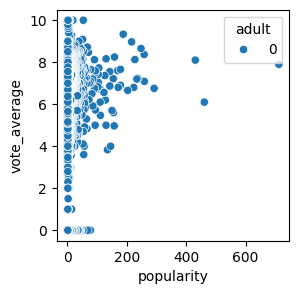

In [41]:
sns.scatterplot(data=df_movie, x='popularity', y='vote_average',hue='adult')
plt.show()

# **FEATURE ENGINEERING / AUGMENTATION**

### Extract year/month/day

In [44]:
df_movie['year'] = pd.to_datetime(df_movie['release_date']).dt.year
df_movie['month'] = pd.to_datetime(df_movie['release_date']).dt.month
df_movie['day'] = pd.to_datetime(df_movie['release_date']).dt.day
df_movie.head(2)

,id,adult,title,release_date,popularity,vote_average,vote_count,weighted_rating,year,month,day
0,1339713,0,Obsession,2026-05-13,711.9924,7.9,525,6.689186,2026.0,5.0,13.0
1,1433117,0,Kara,2026-04-30,461.3196,6.1,15,6.311614,2026.0,4.0,30.0


### Popularity categories

In [51]:
df_movie['popularity_level'] = pd.cut(df_movie['popularity'],
                                      bins=[0,10,50,100,1000],
                                      labels=['low','medium','high','viral'])
df_movie.head(5)


,id,adult,title,release_date,popularity,vote_average,vote_count,weighted_rating,year,month,day,popularity_level
0,1339713,0,Obsession,2026-05-13,711.9924,7.900,525,6.689186,2026.0,5.0,13.0,viral
1,1433117,0,Kara,2026-04-30,461.3196,6.100,15,6.311614,2026.0,4.0,30.0,viral
2,1304313,0,Lee Cronin's The Mummy,2026-04-15,430.9474,8.100,1580,7.176169,2026.0,4.0,15.0,viral
3,1083381,0,Backrooms,2026-05-27,292.4706,6.755,320,6.383710,2026.0,5.0,27.0,viral
4,1380291,0,Tom Clancy's Jack Ryan: Ghost War,2026-05-20,259.5000,7.088,476,6.483539,2026.0,5.0,20.0,viral


### Rating categories

In [62]:
df_movie['rating+category'] = pd.cut(df_movie['vote_average'],
                                     bins = [0,4,6,8,10],
                                     labels=['bad','average','good','excellent'])
df_movie.head(5)

,id,adult,title,release_date,popularity,vote_average,vote_count,weighted_rating,year,month,day,popularity_level,rating+category
0,1339713,0,Obsession,2026-05-13,711.9924,7.900,525,6.689186,2026.0,5.0,13.0,viral,good
1,1433117,0,Kara,2026-04-30,461.3196,6.100,15,6.311614,2026.0,4.0,30.0,viral,good
2,1304313,0,Lee Cronin's The Mummy,2026-04-15,430.9474,8.100,1580,7.176169,2026.0,4.0,15.0,viral,excellent
3,1083381,0,Backrooms,2026-05-27,292.4706,6.755,320,6.383710,2026.0,5.0,27.0,viral,good
4,1380291,0,Tom Clancy's Jack Ryan: Ghost War,2026-05-20,259.5000,7.088,476,6.483539,2026.0,5.0,20.0,viral,good


## Key Insights